
# 2. Correlación cruzada entre Calamar y las otras estaciones

Debido a que las estaciones de Achí y El Banco se encuentran a varios cientos de kilómetros de la estación Calamar, se espera que exista un retardo
temporal entre las variables explicativas y la serie objetivo. Por lo tanto, se realiza inicialmente un análisis de correlación cruzada con el fin 
de identificar el desfase temporal más representativo y desplazar las series de tiempo de las variables explicativas según el lag encontrado, de manera
que se maximice su correlación con la estación de Calamar.

Achi -> Calamar: mejor lag = 12 días, correlación = 0.7148
El Banco -> Calamar: mejor lag = 7 días, correlación = 0.9127


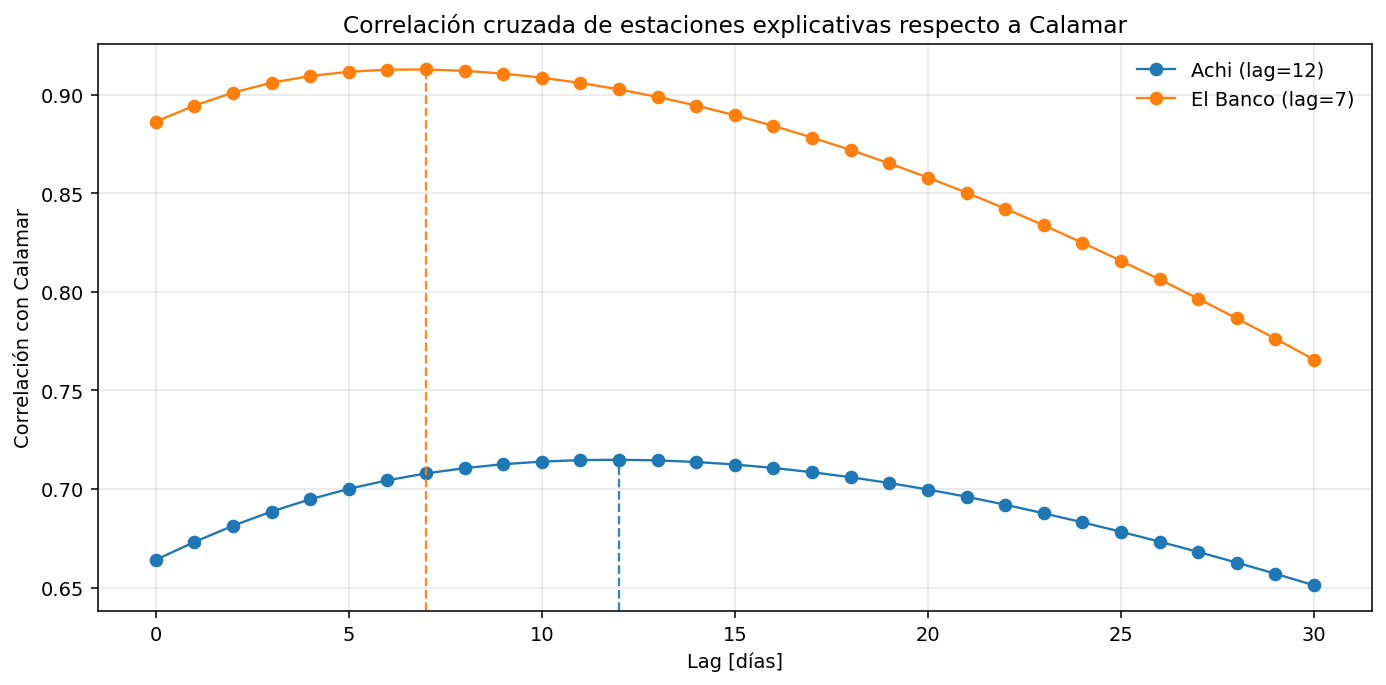

In [11]:
import pandas as pd
import matplotlib.pyplot as plt


# Rutas
rutas = {
    "Achi": r"C:\Users\Victus\Documents\Academico\MCT\Semestre2\MachineLearning\PF\DatosNivel\AchiNivelMedioDiarioCompleto.csv",
    "Calamar": r"C:\Users\Victus\Documents\Academico\MCT\Semestre2\MachineLearning\PF\DatosNivel\CalamarNivelMedioDiarioCompleto.csv",
    "ElBanco": r"C:\Users\Victus\Documents\Academico\MCT\Semestre2\MachineLearning\PF\DatosNivel\ElBancoNivelMedioDiarioCompleto.csv"
}


# Lectura
def leer_nivel(ruta, nombre):
    df = pd.read_csv(ruta, parse_dates=["Fecha"])
    df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce")
    df["Nivel"] = pd.to_numeric(df["Nivel"], errors="coerce")
    df = df.dropna(subset=["Fecha", "Nivel"]).sort_values("Fecha")
    return df[["Fecha", "Nivel"]].rename(columns={"Nivel": nombre})

df = None
for nombre, ruta in rutas.items():
    dfi = leer_nivel(ruta, nombre)
    df = dfi if df is None else df.merge(dfi, on="Fecha", how="inner")

df = df.sort_values("Fecha").reset_index(drop=True)


# Correlación cruzada
# lag > 0 significa que la explicativa ocurre antes que Calamar
def correlacion_cruzada(df, explicativa, target="Calamar", max_lag=30):
    resultados = []
    for lag in range(0, max_lag + 1):
        r = df[explicativa].shift(lag).corr(df[target])
        resultados.append((lag, r))
    out = pd.DataFrame(resultados, columns=["lag_dias", "corr"])
    mejor = out.loc[out["corr"].idxmax()]
    return out, int(mejor["lag_dias"]), float(mejor["corr"])

ccf_achi, lag_achi, corr_achi = correlacion_cruzada(df, "Achi", "Calamar", max_lag=30)
ccf_banco, lag_banco, corr_banco = correlacion_cruzada(df, "ElBanco", "Calamar", max_lag=30)

print(f"Achi -> Calamar: mejor lag = {lag_achi} días, correlación = {corr_achi:.4f}")
print(f"El Banco -> Calamar: mejor lag = {lag_banco} días, correlación = {corr_banco:.4f}")

# Aplicar shifts óptimos
df["Achi_shift"] = df["Achi"].shift(lag_achi)
df["ElBanco_shift"] = df["ElBanco"].shift(lag_banco)


# Gráfica correlación cruzada
fig, ax = plt.subplots(figsize=(10, 5), dpi=140)

l1, = ax.plot(ccf_achi["lag_dias"], ccf_achi["corr"], marker="o", lw=1.2, label=f"Achi (lag={lag_achi})")
l2, = ax.plot(ccf_banco["lag_dias"], ccf_banco["corr"], marker="o", lw=1.2, label=f"El Banco (lag={lag_banco})")

  # Ajustes lineas verticales de la gráfica
ymin, ymax = ax.get_ylim()
ax.vlines(lag_achi, ymin=ymin, ymax=corr_achi,
          color=l1.get_color(), linestyle="--", linewidth=1.2, alpha=0.9)

ax.vlines(lag_banco, ymin=ymin, ymax=corr_banco,
          color=l2.get_color(), linestyle="--", linewidth=1.2, alpha=0.9)


ax.set_ylim(ymin, ymax)
ax.set_xlabel("Lag [días]")
ax.set_ylabel("Correlación con Calamar")
ax.set_title("Correlación cruzada de estaciones explicativas respecto a Calamar")
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

#Guardar las series finales
df_guardar = df[["Fecha", "Calamar", "Achi_shift", "ElBanco_shift"]].copy()
df_guardar.to_csv(
    r"C:\Users\Victus\Documents\Academico\MCT\Semestre2\MachineLearning\PF\DatosNivel\Niveles_alineados.csv",
    index=False
)
